In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow as tf 
import seaborn as sns
from tensorflow import keras 
from keras.models import Sequential 
from keras.layers import Dense 
from keras.optimizers import Adam
from keras.layers import Dropout

In [36]:
import numpy as np

np.random.seed(42)

# Small dataset
n_samples = 100

# Two input features
x = np.random.uniform(-3, 3, (n_samples, 2))

# Non-linear regression function
y = (
    2 * np.sin(x[:, 0]) +
    0.5 * x[:, 1]**2
)

# Add noise
noise = np.random.normal(0, 0.5, n_samples)
y = y + noise

# Reshape for Keras
y = y.reshape(-1, 1)

print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (100, 2)
Y shape: (100, 1)


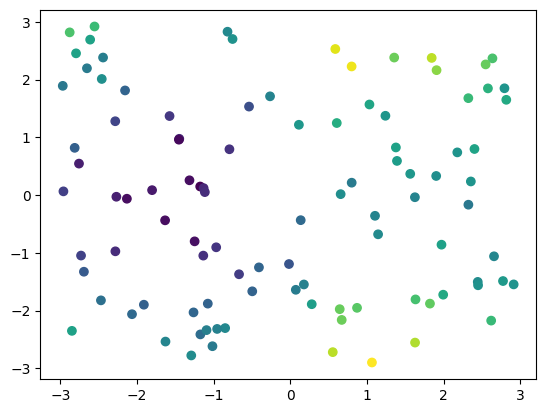

In [37]:
plt.scatter(x[: ,0] , x[: , 1] , c =y)

In [38]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x ,y ,test_size=0.2 , random_state= 42)

# Regression Model

In [56]:
model = Sequential()

model.add(Dense(128 , input_dim = 2 , activation= 'relu'))
model.add(Dense(128  , activation= 'relu'))
model.add(Dense(1  , activation= 'linear'))

adam = Adam(learning_rate = 0.01)
model.compile(loss= 'mse' , optimizer= adam , metrics= ['mse'])

history = model.fit(x_train , y_train , validation_data= (x_test , y_test) , epochs= 2000 , verbose= False)

In [57]:
#Evaluating model
_, train_mse = model.evaluate(x_train , y_train)
_, test_mse = model.evaluate(x_test , y_test)
print("Train: {} , Test: {}".format(train_mse , test_mse))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0143 - mse: 0.0143 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4687 - mse: 0.4687
Train: 0.014260338619351387 , Test: 0.46874743700027466


In [58]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


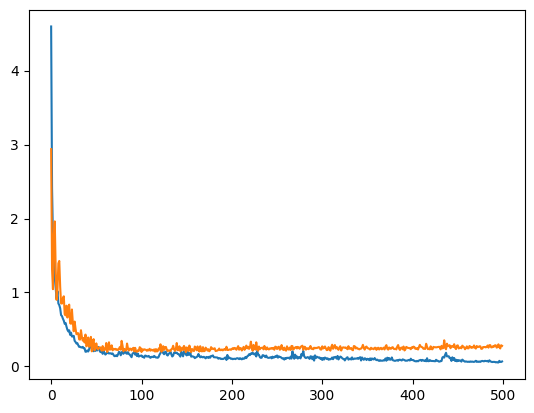

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Dropout model

In [68]:
model = Sequential()

model.add(Dense(128, input_dim=2, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

history = model.fit(x_train, y_train, validation_data=(
    x_test, y_test), epochs=2000, verbose=False)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
# Evaluating model
_, train_mse = model.evaluate(x_train, y_train)
_, test_mse = model.evaluate(x_test, y_test)
print("Train: {} , Test: {}".format(train_mse, test_mse))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3345 - mse: 0.3345 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3501 - mse: 0.3501
Train: 0.3345314860343933 , Test: 0.3501400351524353


In [70]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


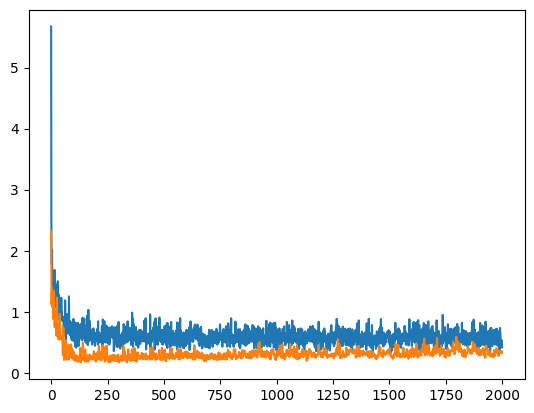

In [71]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])